# Making a decision tree that shows the most important splits in the dataset

In [25]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
import pandas as pd
from sklearn.model_selection import train_test_split
from pyhere import here
import itertools
import numpy as np

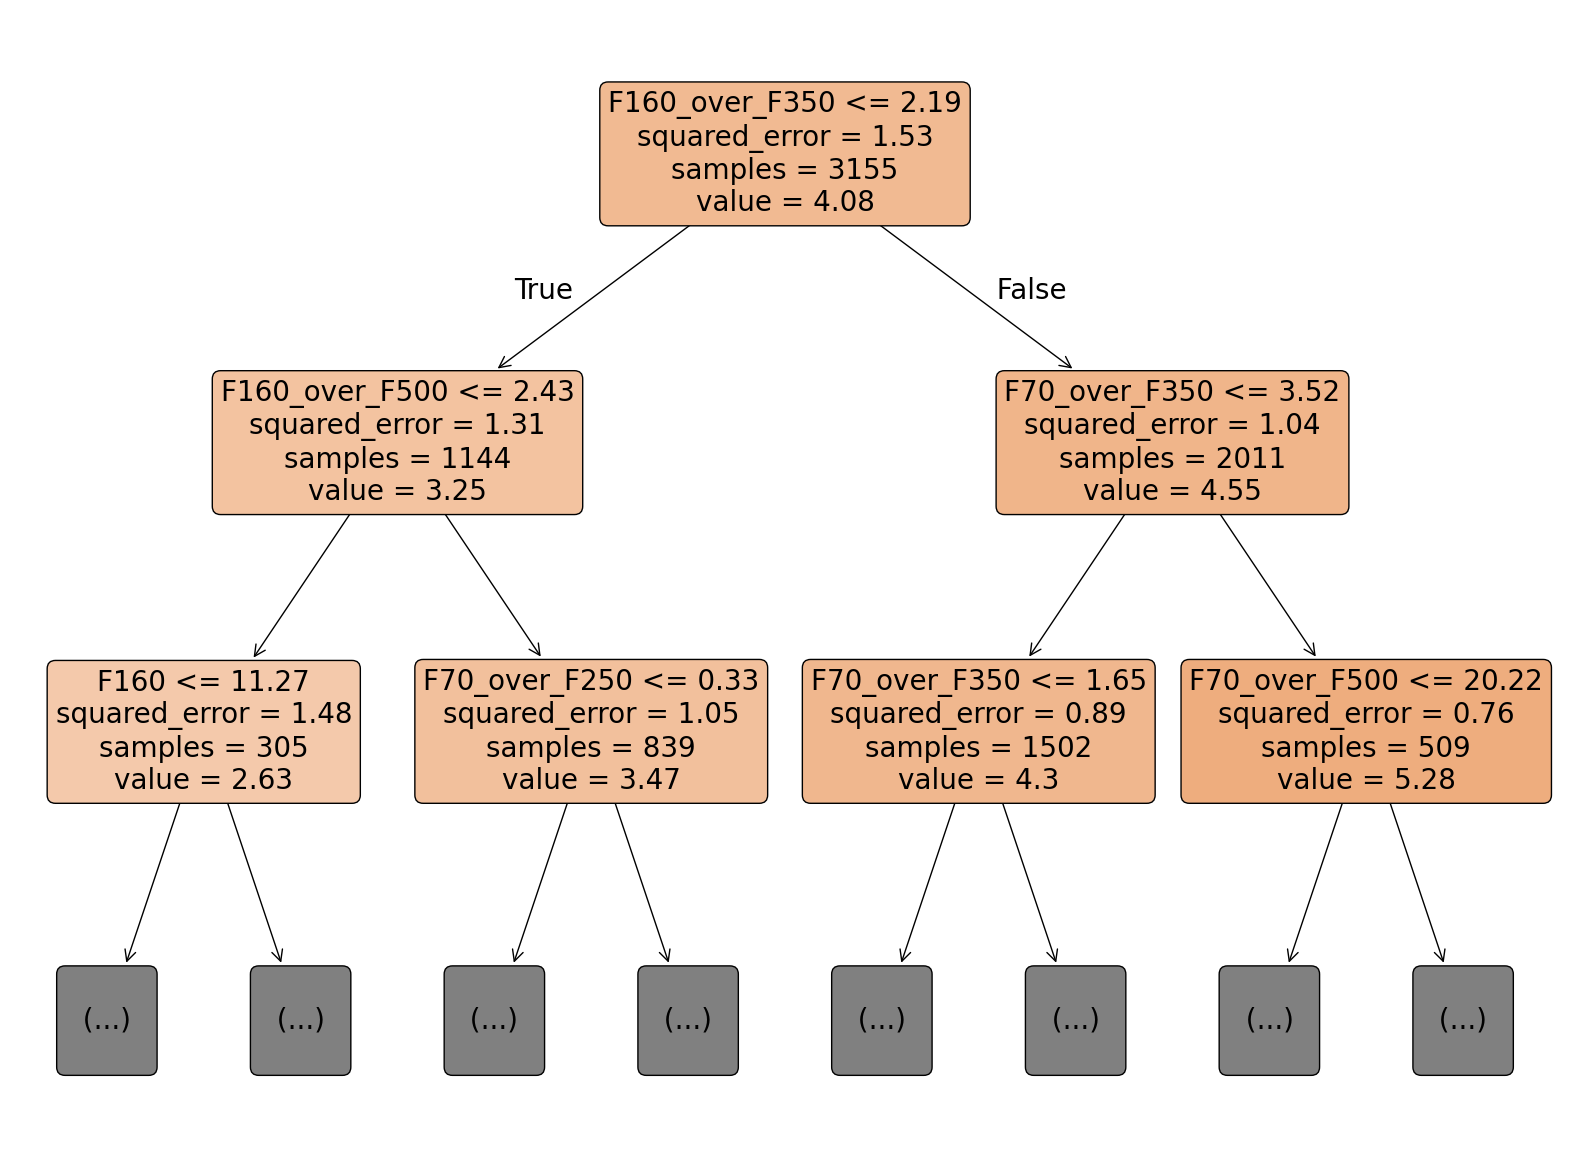

In [ ]:
phot = pd.read_csv(here("data/cleaned", "MIRION_cleaned_everything.csv"))

remove_properties = [
        'T_BOL',  
        'LM', 
        'L_BOL', 
        'MASS', 
        'DIAM', 
        'SURF_DENS', 
        'YB',
        'LRATIO',
        'TEMP'
        ]

flux_cols = ['F8', 'F12', 'F24', 'F70', 'F160', 'F250', 'F350', 'F500', 'F870', 'F1100']

for top, bottom in itertools.combinations(flux_cols, 2):
    new_col_name = f"{top}_over_{bottom}"
    phot[new_col_name] = phot[top] / phot[bottom]

X = phot.drop(columns=remove_properties)
X_train, X_test, y_train, y_test = train_test_split(X, np.log(phot['LRATIO']), random_state=2026, test_size=0.2)

reg = DecisionTreeRegressor(random_state=42)
reg.fit(X_train, y_train)

# 3. Plot the Tree
plt.figure(figsize=(20, 15)) # Adjust size as needed for your screen
plot_tree(
    reg, 
    feature_names=X.columns.tolist(),  
    filled=True,                  # Colors map to the predicted continuous value
    rounded=True,                 
    fontsize=20,                   
    precision=2,
    max_depth=2
)

plt.savefig(here('graphing/graphs/miscellanious', 'decision_tree_lrat_visual.png'), dpi=300, bbox_inches='tight')

plt.show()

